# This notebook looks at output from a series of DAPyR experiments to look at differences between the "direct" likelihood estimation method and the original approach we looked at, which found the nearest states and obs in the training data.


## We start with some imports and initial setup:

In [1]:
import numpy as np
import sys
sys.path.insert(0,'..')
import DAPyr as dap
import DAPyr.MISC
import matplotlib.pyplot as plt
from scipy.stats import norm
from importlib import reload
import matplotlib as mpl
import matplotlib.colors as mcolors
import pickle
from ipywidgets import *

reload(dap)

<module 'DAPyr' from '/Users/etto/research/DAPyr-nle/src/notebooks/../DAPyr/__init__.py'>

In [2]:
#poep = {'mu': 0, 'sigma': 1.0} 
#uoep = {'mu': 0, 'sigma': 1.0} 
# ^ original v best cauchy
poep = {'mu': 0, 'sigma': 0.5} 
uoep = {'mu': 0, 'sigma': 0.5} 
# original experiments were gamma = 0.2!
uoep_sd = {'mu1': -2.0, 'sigma1': 1, 'mu2': 2.0, 'sigma2':1, 'threshold': 0}
poep_sd = {'mu1': -2.0, 'sigma1': 1, 'mu2': 2.0, 'sigma2':1, 'threshold': 0}

uoep_cauchy = {'x0': 0, 'gamma': 0.34}
poep_cauchy = {'x0': 0, 'gamma': 0.34} 

## The first set of experiments we'll look at is where obs errors are Cauchy (this is hard!). Below are some experiments we'll run. We have experiments with small training data (n=100) and large training data (n=500), computing with the direct approach and the "nearest" approach. This first round of experiments will train on the true state.

In [3]:
e_name = 'L96: cauchy'
print(f'starting experiment {e_name}')
bw = 0.01
knn = 0.05
# original experiments!
#bw = 0.02
#knn = 0.1
klb=0.0
e_small_training = dap.Expt('L96: Direct p(y|x), Small Training', {'expt_flag': 3,
                       'model_flag':1,
                       'localize':1,
                       'obf': 2,
                       'seed': 58,
                       'qc_flag': 0,
                       'used_obs_err': 3,
                       'prescribed_obs_err': 0,
                       'used_obs_err_params': uoep_cauchy,
                       'prescribed_obs_err_params': poep,
                       'compute_pyx_directly': True,
                       'save_keest_pab':1,
                       'Ne':80,
                       'tau': 1,
                       'T': 1500,
                       'T_train': 100,
                       'nle_type': 4,
                       'nle_every': 50, 
                       'Neig': 50,
                       'knn_frac': knn,
                       'bw_dm': bw,
                       'klb':klb,
                       'debug_nle_noDA': False})
e_small_training_nearest = dap.Expt('L96: Nearest p(y|x), Small Training', {'expt_flag': 3,
                       'model_flag':1,
                       'localize':1,
                       'obf': 2,
                       'seed': 58,
                       'qc_flag': 0,
                       'used_obs_err': 3,
                       'prescribed_obs_err': 0,
                       'used_obs_err_params': uoep_cauchy,
                       'prescribed_obs_err_params': poep,
                       'compute_pyx_directly': False,
                       'save_keest_pab':1,
                       'Ne':80,
                       'tau': 1,
                       'T': 1500,
                       'T_train': 100,
                       'nle_type': 4,
                       'nle_every': 50, 
                       'Neig': 50,
                       'knn_frac': knn,
                       'bw_dm': bw,
                       'klb':klb,
                       'debug_nle_noDA': False})
e_large_training = dap.Expt('L96: Direct p(y|x), Large Training ', {'expt_flag': 3,
                       'model_flag':1,
                       'localize':1,
                       'obf': 2,
                       'seed': 58,
                       'qc_flag': 0,
                       'used_obs_err': 3,
                       'prescribed_obs_err': 0,
                       'used_obs_err_params': uoep_cauchy,
                       'prescribed_obs_err_params': poep,
                       'compute_pyx_directly': True,
                       'save_keest_pab':1,
                       'Ne':80,
                       'tau': 1,
                       'T': 1500,
                       'T_train': 500,
                       'nle_type': 4,
                       'nle_every': 50, 
                       'Neig': 50,
                       'knn_frac': knn,
                       'bw_dm': bw,
                       'klb':klb,
                       'debug_nle_noDA': False})
e_large_training_nearest = dap.Expt('L96: Nearest p(y|x), Large Training', {'expt_flag': 3,
                       'model_flag':1,
                       'localize':1,
                       'obf': 2,
                       'seed': 58,
                       'qc_flag': 0,
                       'used_obs_err': 3,
                       'prescribed_obs_err': 0,
                       'used_obs_err_params': uoep_cauchy,
                       'prescribed_obs_err_params': poep,
                       'compute_pyx_directly': False,
                       'save_keest_pab':1,
                       'Ne':80,
                       'tau': 1,
                       'T': 1500,
                       'T_train': 500,
                       'nle_type': 4,
                       'nle_every': 50, 
                       'Neig': 50,
                       'knn_frac': knn,
                       'bw_dm': bw,
                       'klb':klb,
                       'debug_nle_noDA': False})

starting experiment L96: cauchy


## For each of the above experiments, we save the computed conditional embedding operator the first time it is computed (i.e. one for n=100 and one for n=500), as well as the training data itself. I also saved an ensemble/observation at three different times so that we can go back later and look at embeddings quickly.

starting small training experiment - direct calc
DB: Starting cycle 0
DB: Starting cycle 100
DB: Starting cycle 200
DB: Starting cycle 300
DB: Starting cycle 400
run DA error
starting small nearest training experiment - nearest calc


/Users/etto/research/DAPyr-nle/src/notebooks/../DAPyr/MISC.py:338: RuntimeWarning: divide by zero encountered in divide
  alphaNew = 1.0 / np.sqrt(row_sum_new)
/Users/etto/research/DAPyr-nle/src/notebooks/../DAPyr/MISC.py:342: RuntimeWarning: invalid value encountered in multiply
  T *= alphaNew


DB: Starting cycle 0
DB: Starting cycle 100
DB: Starting cycle 200
DB: Starting cycle 300
DB: Starting cycle 400


/Users/etto/research/DAPyr-nle/src/notebooks/../DAPyr/MISC.py:338: RuntimeWarning: divide by zero encountered in divide
  alphaNew = 1.0 / np.sqrt(row_sum_new)
/Users/etto/research/DAPyr-nle/src/notebooks/../DAPyr/MISC.py:342: RuntimeWarning: invalid value encountered in multiply
  T *= alphaNew


DB: Starting cycle 500


...

DB: Starting cycle 600
DB: Starting cycle 700
DB: Starting cycle 800
DB: Starting cycle 900
DB: Starting cycle 1000


/Users/etto/research/DAPyr-nle/src/notebooks/../DAPyr/MISC.py:338: RuntimeWarning: divide by zero encountered in divide
  alphaNew = 1.0 / np.sqrt(row_sum_new)
/Users/etto/research/DAPyr-nle/src/notebooks/../DAPyr/MISC.py:342: RuntimeWarning: invalid value encountered in multiply
  T *= alphaNew


DB: Starting cycle 1100


/Users/etto/research/DAPyr-nle/src/notebooks/../DAPyr/MISC.py:338: RuntimeWarning: divide by zero encountered in divide
  alphaNew = 1.0 / np.sqrt(row_sum_new)
/Users/etto/research/DAPyr-nle/src/notebooks/../DAPyr/MISC.py:342: RuntimeWarning: invalid value encountered in multiply
  T *= alphaNew
/Users/etto/research/DAPyr-nle/src/notebooks/../DAPyr/MISC.py:338: RuntimeWarning: divide by zero encountered in divide
  alphaNew = 1.0 / np.sqrt(row_sum_new)
/Users/etto/research/DAPyr-nle/src/notebooks/../DAPyr/MISC.py:342: RuntimeWarning: invalid value encountered in multiply
  T *= alphaNew


DB: Starting cycle 1200
DB: Starting cycle 1300
DB: Starting cycle 1400
starting large training experiment - direct calc
DB: Starting cycle 0
DB: Starting cycle 100
DB: Starting cycle 200
DB: Starting cycle 300
DB: Starting cycle 400
DB: Starting cycle 500
DB: Starting cycle 600
DB: Starting cycle 700
DB: Starting cycle 800
DB: Starting cycle 900
DB: Starting cycle 1000
DB: Starting cycle 1100
DB: Starting cycle 1200
DB: Starting cycle 1300
DB: Starting cycle 1400
starting large training experiment - nearest calc
DB: Starting cycle 0
DB: Starting cycle 100
DB: Starting cycle 200
DB: Starting cycle 300
DB: Starting cycle 400
DB: Starting cycle 500
DB: Starting cycle 600
DB: Starting cycle 700
DB: Starting cycle 800
DB: Starting cycle 900
DB: Starting cycle 1000
DB: Starting cycle 1100
DB: Starting cycle 1200
DB: Starting cycle 1300
DB: Starting cycle 1400


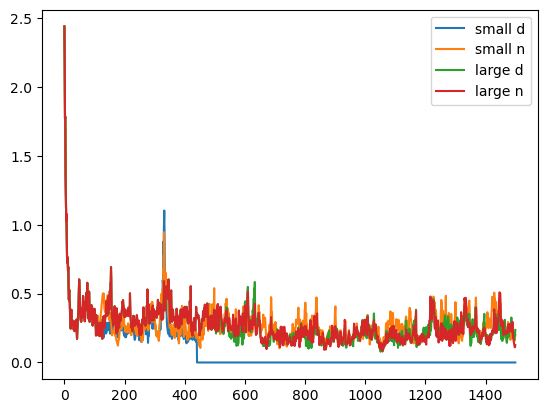

In [4]:
print('starting small training experiment - direct calc')
dap.runDA(e_small_training)
print('starting small nearest training experiment - nearest calc')
dap.runDA(e_small_training_nearest)
print('starting large training experiment - direct calc')
dap.runDA(e_large_training)
print('starting large training experiment - nearest calc')
dap.runDA(e_large_training_nearest)

plt.plot(e_small_training.rmse, label='small d')
plt.plot(e_small_training_nearest.rmse, label = 'small n')
plt.plot(e_large_training.rmse, label = 'large d')
plt.plot(e_large_training_nearest.rmse, label='large n')
plt.legend()
plt.show()

## Having run these experiments, we can look at computed particle weights at different times with each method for each training size. See below widget! The next two cells recreate the direct and nearest computations given the input data and the computed embeddings and training data, and then load all that information in.

In [5]:
def compute_by_direct(input_file, kde_file, map_file):
    with open(kde_file, "rb") as f:
        y_kde = pickle.load(f)
    
    inputs = np.load(input_file)
    hxb_nbrs, Y = inputs['hxb_nbrs'], inputs['Y']
    print(Y[0,0,:].shape)

    map_info = np.load(map_file)
    x_train = map_info['x_train']
    y_train = map_info['y_train']
    evec_x = map_info['evec_x']           
    eval_x = map_info['eval_x']            
    a_train_x = map_info['a_train_x']      
    evec_y = map_info['evec_y']         
    eval_y = map_info['eval_y']         
    a_train_y = map_info['a_train_y']        
    cov_embedding = map_info['cov_embedding']
    bwx = map_info['bwx']
    bwy = map_info['bwy']
    knn=map_info['knn']
    Ns=1

    a_train_x = np.asarray(a_train_x).squeeze()
    a_train_y = np.asarray(a_train_y).squeeze()


    Ny, Ne, Neig = 20, 80, 50

    V_new_obs = np.zeros((Ny, Neig+1))
    V_new_state = np.zeros((Ny, Ne, Neig+1))
    new_obs_kde = np.zeros(Ny)
    t = int(input_file.split('_')[-1].split('.')[0])

    for k in range(Ny):
          # print('k is {}p'.format(k))
          V_new_obs[k] = DAPyr.MISC.diff_map_ext_nystrom(Y[k,t,:].T,y_train.T,evec_y,eval_y,a_train_y,bwy,knn,1);
          new_obs_kde[k] = y_kde(Y[k,t,:])

          for n in range(Ne):
                V_new_state[k,n] = DAPyr.MISC.diff_map_ext_nystrom(
                      hxb_nbrs[:, k, n].reshape(1, -1),
                      x_train.T,
                      evec_x,
                      eval_x,
                      a_train_x,
                      bwx,
                      knn,
                      Ns,
                )
    temp = V_new_obs @ cov_embedding
    wo2 = np.einsum('kd, knd->kn', temp, V_new_state)
    wo2 *= new_obs_kde[:,None]
    
    wo2 = np.maximum(wo2, 0)
    #wo2 = np.real(wo2) + 1e-40
    for k in range(Ny):
          wo2[k, :] /= np.sum(wo2[k, :])
    return wo2

    
def compute_by_nearest(input_file, kde_file, map_file):
    with open(kde_file, "rb") as f:
        y_kde = pickle.load(f)
    
    inputs = np.load(input_file)
    hxb_nbrs, Y = inputs['hxb_nbrs'], inputs['Y']
    t = int(input_file.split('_')[-1].split('.')[0])

    map_info = np.load(map_file)
    x_train = map_info['x_train']
    y_train = map_info['y_train']
    evec_x = map_info['evec_x']           
    eval_x = map_info['eval_x']            
    a_train_x = map_info['a_train_x']      
    evec_y = map_info['evec_y']         
    eval_y = map_info['eval_y']         
    a_train_y = map_info['a_train_y']        
    cov_embedding = map_info['cov_embedding']
    bwx = map_info['bwx']
    bwy = map_info['bwy']
    knn=map_info['knn']
    pab=map_info['pab']
    Ns=1

    x_emb = (evec_x * eval_x).T
    y_emb = (evec_y * eval_y).T


    a_train_x = np.asarray(a_train_x).squeeze()
    a_train_y = np.asarray(a_train_y).squeeze()

    nle_type=4

    Ny, Ne, Neig = 20, 80, 50
    wo = np.zeros((Ny,Ne))

    for k in range(Ny):
      if nle_type >= 4 :
            # print('k is {}p'.format(k))
            obs_emb = DAPyr.MISC.diff_map_ext_nystrom(Y[k,t,:].T,y_train.T,evec_y,eval_y,a_train_y,bwy,knn,1);
            V_new_obs = obs_emb
            obs_emb *= eval_y
            ind2 = np.argmin(np.sum((obs_emb.T - y_emb) ** 2, axis=0))
      for n in range(Ne):
            if nle_type < 4:
                  obs_emb = DAPyr.MISC.diff_map_ext_nystrom(
      # y_train[ts:te] = Y[t,0::tof]
                        (Y[k,t,:] - hxb_nbrs[(Nxy - 1) // 2, k, n]).T,
                        y_train.T,
                        evec_y,
                        eval_y,
                        a_train_y,
                        bwy,
                        knn,
                        1,
                  )
                  obs_emb *= eval_y  # Element-wise multiplication along columns
                  ind2 = np.argmin(np.sum((obs_emb.T - y_emb) ** 2, axis=0))
            # Find nearest state on manifold
            state_emb = DAPyr.MISC.diff_map_ext_nystrom(
                  hxb_nbrs[:, k, n].reshape(1, -1),
                  x_train.T,
                  evec_x,
                  eval_x,
                  a_train_x,
                  bwx,
                  knn,
                  Ns,
            )
            state_emb *= eval_x  # Element-wise multiplication along columns
            ind1 = np.argmin(np.sum((state_emb.T - x_emb) ** 2, axis=0))
            wo[k,n] = pab[ind2, ind1]

# sum of normalized likelihoods for a given observation equals one
      wo[k, :] /= np.sum(wo[k, :])
    return wo


In [6]:
path = 'data/direct_v_nearest_pyx_calc/'
wo_t110_n100_dir = compute_by_direct(path + 'test_data_110.npz', path + 'kde_100.pkl', path + 'maps_100.npz')
wo_t120_n100_dir = compute_by_direct(path + 'test_data_120.npz', path + 'kde_100.pkl', path + 'maps_100.npz')
wo_t130_n100_dir = compute_by_direct(path + 'test_data_130.npz', path + 'kde_100.pkl', path + 'maps_100.npz')
wo_t110_n500_dir = compute_by_direct(path + 'test_data_110.npz', path + 'kde_500.pkl', path + 'maps_500.npz')
wo_t120_n500_dir = compute_by_direct(path + 'test_data_120.npz', path + 'kde_500.pkl', path + 'maps_500.npz')
wo_t130_n500_dir = compute_by_direct(path + 'test_data_130.npz', path + 'kde_500.pkl', path + 'maps_500.npz')
wo_t110_n100_nr = compute_by_nearest(path + 'test_data_110.npz', path + 'kde_100.pkl', path + 'maps_100.npz')
wo_t120_n100_nr = compute_by_nearest(path + 'test_data_120.npz', path + 'kde_100.pkl', path + 'maps_100.npz')
wo_t130_n100_nr = compute_by_nearest(path + 'test_data_130.npz', path + 'kde_100.pkl', path + 'maps_100.npz')
wo_t110_n500_nr = compute_by_nearest(path + 'test_data_110.npz', path + 'kde_500.pkl', path + 'maps_500.npz')
wo_t120_n500_nr = compute_by_nearest(path + 'test_data_120.npz', path + 'kde_500.pkl', path + 'maps_500.npz')
wo_t130_n500_nr = compute_by_nearest(path + 'test_data_130.npz', path + 'kde_500.pkl', path + 'maps_500.npz')

(1,)


/var/folders/8j/k_hxvb2s6ts__zmjbc2qn9q80000gn/T/ipykernel_27074/1179857395.py:38: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  new_obs_kde[k] = y_kde(Y[k,t,:])


(1,)
(1,)
(1,)
(1,)
(1,)


In [7]:
x = np.arange(80)
width=0.4
def plot_row(row, size, time):
    plt.figure(figsize=(10, 4))

    if size=='Large':
        if time == '1':
            d1 = wo_t110_n500_dir
            d2 = wo_t110_n500_nr
        elif time=='2':
            d1 = wo_t120_n500_dir
            d2 = wo_t120_n500_nr
        elif time=='3':
            d1 = wo_t130_n500_dir
            d2 = wo_t130_n500_nr
    elif size=='Small':
        if time == '1':
            d1 = wo_t110_n100_dir
            d2 = wo_t110_n100_nr
        elif time=='2':
            d1 = wo_t120_n100_dir
            d2 = wo_t120_n100_nr
        elif time=='3':
            d1 = wo_t130_n100_dir
            d2 = wo_t130_n100_nr

    
    plt.bar(x - width/2, d1[row], width, label='direct')
    plt.bar(x + width/2, d2[row], width, label='nearest')

    plt.ylim(0,0.07)
    
    plt.legend()
    plt.title(f"Cauchy Truth Experiment: {size} Training: Obs #{row}")
    plt.xlabel("Ensemble Member")
    plt.ylabel("Computed Particle Weights")
    
    plt.show()

interact(
    plot_row,
    row=IntSlider(min=0, max=len(wo_t110_n100_dir)-1, step=1, value=0),
    size=RadioButtons(options=['Large', 'Small'], description='Dataset:'),
    time=RadioButtons(options=['1', '2','3'], description='Time:')
)

interactive(children=(IntSlider(value=0, description='row', max=19), RadioButtons(description='Dataset:', opti…

<function __main__.plot_row(row, size, time)>

## It seems that the two methods agree most of the time pretty well - with the exception being observation number 6 at t=130. Let's see if we can figure out what's going on there. The below widget now lets us actually look at the ensemble and obs at the three times I've saved:

In [8]:
def plot_ens(obs, time):

    if time == '1':
        data = np.load('data/direct_v_nearest_pyx_calc/test_data_110.npz')
    elif time == '2':
        data = np.load('data/direct_v_nearest_pyx_calc/test_data_120.npz')
    elif time == '3':
        data = np.load('data/direct_v_nearest_pyx_calc/test_data_130.npz')

    hxb_data = data['hxb_nbrs']
    y_data = data['Y']

    t = 110 if time == '1' else 120 if time == '2' else 130
    y_t = y_data[:,t,:]
        
    plt.figure(figsize=(10, 4))

    plt.scatter(x, hxb_data[0,obs],s=20, label='ensemble members' , c='black')

    plt.plot(x, np.ones(80) * y_t[obs], c='red', label='Observation')
    
    plt.legend()
    plt.ylim(-10,13)
    plt.title(f"t=130; obs# ={obs}")
    plt.xlabel("Ensemble Member")
    plt.ylabel("Value")
    
    plt.show()

interact(
    plot_ens,
    obs=IntSlider(min=0, max=19, step=1, value=0),
    time=RadioButtons(options=['1', '2','3'], description='Time:')
)

interactive(children=(IntSlider(value=0, description='obs', max=19), RadioButtons(description='Time:', options…

<function __main__.plot_ens(obs, time)>

## Next, we repeat this whole song and dance with Gaussian obs errors:

In [9]:
e_name = 'L96: cauchy'
print(f'starting experiment {e_name}')
bw = 0.01
knn = 0.05
# original experiments!
#bw = 0.02
#knn = 0.1
klb=0.0
e_small_training_gauss = dap.Expt('L96: Direct p(y|x), Small, Gaussian', {'expt_flag': 3,
                       'model_flag':1,
                       'localize':1,
                       'obf': 2,
                       'seed': 58,
                       'qc_flag': 0,
                       'used_obs_err': 0,
                       'prescribed_obs_err': 0,
                       'used_obs_err_params': uoep,
                       'prescribed_obs_err_params': poep,
                       'compute_pyx_directly': True,
                       'save_keest_pab':1,
                       'Ne':80,
                       'tau': 1,
                       'T': 1500,
                       'T_train': 100,
                       'nle_type': 4,
                       'nle_every': 50, 
                       'Neig': 50,
                       'knn_frac': knn,
                       'bw_dm': bw,
                       'klb':klb,
                       'debug_nle_noDA': False})
e_small_training_nearest_gauss = dap.Expt('L96: Nearest p(y|x), Small, Gaussian', {'expt_flag': 3,
                       'model_flag':1,
                       'localize':1,
                       'obf': 2,
                       'seed': 58,
                       'qc_flag': 0,
                       'used_obs_err': 0,
                       'prescribed_obs_err': 0,
                       'used_obs_err_params': uoep,
                       'prescribed_obs_err_params': poep,
                       'compute_pyx_directly': True,
                       'save_keest_pab':1,
                       'Ne':80,
                       'tau': 1,
                       'T': 1500,
                       'T_train': 100,
                       'nle_type': 4,
                       'nle_every': 50, 
                       'Neig': 50,
                       'knn_frac': knn,
                       'bw_dm': bw,
                       'klb':klb,
                       'debug_nle_noDA': False})
e_large_training_gauss = dap.Expt('L96: p(y|x), Direct, Large, Gaussian', {'expt_flag': 3,
                       'model_flag':1,
                       'localize':1,
                       'obf': 2,
                       'seed': 58,
                       'qc_flag': 0,
                       'used_obs_err': 0,
                       'prescribed_obs_err': 0,
                       'used_obs_err_params': uoep,
                       'prescribed_obs_err_params': poep,
                       'compute_pyx_directly': True,
                       'save_keest_pab':1,
                       'Ne':80,
                       'tau': 1,
                       'T': 1500,
                       'T_train': 500,
                       'nle_type': 4,
                       'nle_every': 50, 
                       'Neig': 50,
                       'knn_frac': knn,
                       'bw_dm': bw,
                       'klb':klb,
                       'debug_nle_noDA': False})
e_large_training_nearest_gauss = dap.Expt('L96: p(y|x), Nearest, Large, Gaussian', {'expt_flag': 3,
                       'model_flag':1,
                       'localize':1,
                       'obf': 2,
                       'seed': 58,
                       'qc_flag': 0,
                       'used_obs_err': 0,
                       'prescribed_obs_err': 0,
                       'used_obs_err_params': uoep,
                       'prescribed_obs_err_params': poep,
                       'compute_pyx_directly': False,
                       'save_keest_pab':1,
                       'Ne':80,
                       'tau': 1,
                       'T': 1500,
                       'T_train': 500,
                       'nle_type': 4,
                       'nle_every': 50, 
                       'Neig': 50,
                       'knn_frac': knn,
                       'bw_dm': bw,
                       'klb':klb,
                       'debug_nle_noDA': False})

starting experiment L96: cauchy


starting small training experiment
DB: Starting cycle 0
DB: Starting cycle 100
DB: Starting cycle 200
DB: Starting cycle 300
DB: Starting cycle 400
DB: Starting cycle 500
DB: Starting cycle 600
DB: Starting cycle 700
DB: Starting cycle 800
DB: Starting cycle 900
DB: Starting cycle 1000
DB: Starting cycle 1100
DB: Starting cycle 1200
DB: Starting cycle 1300
DB: Starting cycle 1400
starting small training experiment (nearest computation)
DB: Starting cycle 0
DB: Starting cycle 100
DB: Starting cycle 200
DB: Starting cycle 300
DB: Starting cycle 400
DB: Starting cycle 500
DB: Starting cycle 600
DB: Starting cycle 700
DB: Starting cycle 800
DB: Starting cycle 900
DB: Starting cycle 1000
DB: Starting cycle 1100
DB: Starting cycle 1200
DB: Starting cycle 1300
DB: Starting cycle 1400
starting large training experiment
DB: Starting cycle 0
DB: Starting cycle 100
DB: Starting cycle 200
DB: Starting cycle 300
DB: Starting cycle 400
DB: Starting cycle 500
DB: Starting cycle 600
DB: Starting cycle

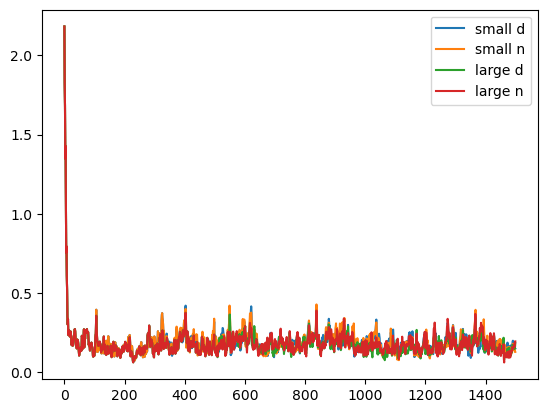

In [10]:
print('starting small training experiment')
dap.runDA(e_small_training_gauss)
print('starting small training experiment (nearest computation)')
dap.runDA(e_small_training_nearest_gauss)
print('starting large training experiment')
dap.runDA(e_large_training_gauss)
print('starting large training experiment (nearest computation)')
dap.runDA(e_large_training_nearest_gauss)


plt.plot(e_small_training_gauss.rmse, label='small d')
plt.plot(e_small_training_nearest_gauss.rmse, label = 'small n')
plt.plot(e_large_training_gauss.rmse, label = 'large d')
plt.plot(e_large_training_nearest_gauss.rmse, label='large n')
plt.legend()
plt.show()


## Looking at computed weights:

In [11]:
path = 'data/direct_v_nearest_pyx_calc/gauss_'

gauss_wo_t110_n100_dir = compute_by_direct(path + 'test_data_110.npz', path + 'kde_100.pkl', path + 'maps_100.npz')
gauss_wo_t120_n100_dir = compute_by_direct(path + 'test_data_120.npz', path + 'kde_100.pkl', path + 'maps_100.npz')
gauss_wo_t130_n100_dir = compute_by_direct(path + 'test_data_130.npz', path + 'kde_100.pkl', path + 'maps_100.npz')
gauss_wo_t110_n500_dir = compute_by_direct(path + 'test_data_110.npz', path + 'kde_500.pkl', path + 'maps_500.npz')
gauss_wo_t120_n500_dir = compute_by_direct(path + 'test_data_120.npz', path + 'kde_500.pkl', path + 'maps_500.npz')
gauss_wo_t130_n500_dir = compute_by_direct(path + 'test_data_130.npz', path + 'kde_500.pkl', path + 'maps_500.npz')
gauss_wo_t110_n100_nr = compute_by_nearest(path + 'test_data_110.npz', path + 'kde_100.pkl', path + 'maps_100.npz')
gauss_wo_t120_n100_nr = compute_by_nearest(path + 'test_data_120.npz', path + 'kde_100.pkl', path + 'maps_100.npz')
gauss_wo_t130_n100_nr = compute_by_nearest(path + 'test_data_130.npz', path + 'kde_100.pkl', path + 'maps_100.npz')
gauss_wo_t110_n500_nr = compute_by_nearest(path + 'test_data_110.npz', path + 'kde_500.pkl', path + 'maps_500.npz')
gauss_wo_t120_n500_nr = compute_by_nearest(path + 'test_data_120.npz', path + 'kde_500.pkl', path + 'maps_500.npz')
gauss_wo_t130_n500_nr = compute_by_nearest(path + 'test_data_130.npz', path + 'kde_500.pkl', path + 'maps_500.npz')

(1,)


/var/folders/8j/k_hxvb2s6ts__zmjbc2qn9q80000gn/T/ipykernel_27074/1179857395.py:38: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  new_obs_kde[k] = y_kde(Y[k,t,:])


(1,)
(1,)
(1,)
(1,)
(1,)


In [12]:
#%matplotlib notebook
x = np.arange(80)
width=0.4
def gauss_plot_row(row, size, time):
    plt.figure(figsize=(10, 4))

    if size=='Large':
        if time == '1':
            d1 = gauss_wo_t110_n500_dir
            d2 = gauss_wo_t110_n500_nr
        elif time=='2':
            d1 = gauss_wo_t120_n500_dir
            d2 = gauss_wo_t120_n500_nr
        elif time=='3':
            d1 = gauss_wo_t130_n500_dir
            d2 = gauss_wo_t130_n500_nr
    elif size=='Small':
        if time == '1':
            d1 = gauss_wo_t110_n100_dir
            d2 = gauss_wo_t110_n100_nr
        elif time=='2':
            d1 = gauss_wo_t120_n100_dir
            d2 = gauss_wo_t120_n100_nr
        elif time=='3':
            d1 = gauss_wo_t130_n100_dir
            d2 = gauss_wo_t130_n100_nr

    
    plt.bar(x - width/2, d1[row], width, label='direct')
    plt.bar(x + width/2, d2[row], width, label='nearest')

    plt.ylim(0,0.07)
    
    plt.legend()
    plt.title(f"Truth, Gaussian Experiment - {size} Training: Obs #{row}")
    plt.xlabel("Ensemble Member")
    plt.ylabel("Computed Particle Weights")
    
    plt.show()

interact(
    gauss_plot_row,
    row=IntSlider(min=0, max=len(gauss_wo_t110_n100_dir)-1, step=1, value=0),
    size=RadioButtons(options=['Large', 'Small'], description='Dataset:'),
    time=RadioButtons(options=['1', '2','3'], description='Time:')
)

interactive(children=(IntSlider(value=0, description='row', max=19), RadioButtons(description='Dataset:', opti…

<function __main__.gauss_plot_row(row, size, time)>

## And, for completeness, looking at each ensemble member/obs in our test input data:

In [13]:
def plot_ens(obs, time):

    if time == '1':
        data = np.load('data/direct_v_nearest_pyx_calc/gauss_test_data_110.npz')
    elif time == '2':
        data = np.load('data/direct_v_nearest_pyx_calc/gauss_test_data_120.npz')
    elif time == '3':
        data = np.load('data/direct_v_nearest_pyx_calc/gauss_test_data_130.npz')

    hxb_data = data['hxb_nbrs']
    y_data = data['Y']

    t = 110 if time == '1' else 120 if time == '2' else 130
    y_t = y_data[:,t,:]
        
    plt.figure(figsize=(10, 4))

    plt.scatter(x, hxb_data[0,obs],s=20, label='ensemble members' , c='black')

    plt.plot(x, np.ones(80) * y_t[obs], c='red', label='Observation')
    
    plt.legend()
    plt.ylim(-10,13)
    plt.title(f"t=130; obs# ={obs}")
    plt.xlabel("Ensemble Member")
    plt.ylabel("Value")
    
    plt.show()

interact(
    plot_ens,
    obs=IntSlider(min=0, max=19, step=1, value=0),
    time=RadioButtons(options=['1', '2','3'], description='Time:')
)

interactive(children=(IntSlider(value=0, description='obs', max=19), RadioButtons(description='Time:', options…

<function __main__.plot_ens(obs, time)>

## This has all been in the context of training on the truth. I would expect any issues that manifest due to insufficient sampling of the manifold to be larger when the manifold we're constructing for the state is potentially biased (in the sense that it is not the same manifold that the true states are living on). Let's repeat at least the Cauchy experiment and see if we get significantly different results from before:

In [14]:
e_name = 'L96: cauchy'
print(f'starting experiment {e_name}')
bw = 0.01
knn = 0.05
# original experiments!
#bw = 0.02
#knn = 0.1
klb=0.0
e_small_training_rsfp = dap.Expt('L96: Direct p(y|x), Small Training', {'expt_flag': 3,
                       'model_flag':1,
                       'localize':1,
                       'obf': 2,
                       'seed': 58,
                       'qc_flag': 0,
                       'used_obs_err': 3,
                       'prescribed_obs_err': 0,
                       'used_obs_err_params': uoep_cauchy,
                       'prescribed_obs_err_params': poep,
                       'compute_pyx_directly': True,
                       'save_keest_pab':1,
                       'Ne':80,
                       'tau': 1,
                       'T': 1500,
                       'T_train': 100,
                       'nle_type': 5,
                       'nle_every': 50, 
                       'Neig': 50,
                       'knn_frac': knn,
                       'bw_dm': bw,
                       'klb':klb,
                       'debug_nle_noDA': False})
e_small_training_nearest_rsfp = dap.Expt('L96: Nearest p(y|x), Small Training', {'expt_flag': 3,
                       'model_flag':1,
                       'localize':1,
                       'obf': 2,
                       'seed': 58,
                       'qc_flag': 0,
                       'used_obs_err': 3,
                       'prescribed_obs_err': 0,
                       'used_obs_err_params': uoep_cauchy,
                       'prescribed_obs_err_params': poep,
                       'compute_pyx_directly': False,
                       'save_keest_pab':1,
                       'Ne':80,
                       'tau': 1,
                       'T': 1500,
                       'T_train': 100,
                       'nle_type': 5,
                       'nle_every': 50, 
                       'Neig': 50,
                       'knn_frac': knn,
                       'bw_dm': bw,
                       'klb':klb,
                       'debug_nle_noDA': False})
e_large_training_rsfp = dap.Expt('L96: Direct p(y|x), Large Training ', {'expt_flag': 3,
                       'model_flag':1,
                       'localize':1,
                       'obf': 2,
                       'seed': 58,
                       'qc_flag': 0,
                       'used_obs_err': 3,
                       'prescribed_obs_err': 0,
                       'used_obs_err_params': uoep_cauchy,
                       'prescribed_obs_err_params': poep,
                       'compute_pyx_directly': True,
                       'save_keest_pab':1,
                       'Ne':80,
                       'tau': 1,
                       'T': 1500,
                       'T_train': 500,
                       'nle_type': 5,
                       'nle_every': 50, 
                       'Neig': 50,
                       'knn_frac': knn,
                       'bw_dm': bw,
                       'klb':klb,
                       'debug_nle_noDA': False})
e_large_training_nearest_rsfp = dap.Expt('L96: Nearest p(y|x), Large Training', {'expt_flag': 3,
                       'model_flag':1,
                       'localize':1,
                       'obf': 2,
                       'seed': 58,
                       'qc_flag': 0,
                       'used_obs_err': 3,
                       'prescribed_obs_err': 0,
                       'used_obs_err_params': uoep_cauchy,
                       'prescribed_obs_err_params': poep,
                       'compute_pyx_directly': False,
                       'save_keest_pab':1,
                       'Ne':80,
                       'tau': 1,
                       'T': 1500,
                       'T_train': 500,
                       'nle_type': 5,
                       'nle_every': 50, 
                       'Neig': 50,
                       'knn_frac': knn,
                       'bw_dm': bw,
                       'klb':klb,
                       'debug_nle_noDA': False})

starting experiment L96: cauchy


starting small training experiment
DB: Starting cycle 0
DB: Starting cycle 100
DB: Starting cycle 200
run DA error
starting small training experiment (nearest computation)


/Users/etto/research/DAPyr-nle/src/notebooks/../DAPyr/MISC.py:338: RuntimeWarning: divide by zero encountered in divide
  alphaNew = 1.0 / np.sqrt(row_sum_new)
/Users/etto/research/DAPyr-nle/src/notebooks/../DAPyr/MISC.py:342: RuntimeWarning: invalid value encountered in multiply
  T *= alphaNew


DB: Starting cycle 0
DB: Starting cycle 100
DB: Starting cycle 200


/Users/etto/research/DAPyr-nle/src/notebooks/../DAPyr/MISC.py:338: RuntimeWarning: divide by zero encountered in divide
  alphaNew = 1.0 / np.sqrt(row_sum_new)
/Users/etto/research/DAPyr-nle/src/notebooks/../DAPyr/MISC.py:342: RuntimeWarning: invalid value encountered in multiply
  T *= alphaNew


DB: Starting cycle 300
DB: Starting cycle 400
DB: Starting cycle 500


...

DB: Starting cycle 1200


/Users/etto/research/DAPyr-nle/src/notebooks/../DAPyr/MISC.py:338: RuntimeWarning: divide by zero encountered in divide
  alphaNew = 1.0 / np.sqrt(row_sum_new)
/Users/etto/research/DAPyr-nle/src/notebooks/../DAPyr/MISC.py:342: RuntimeWarning: invalid value encountered in multiply
  T *= alphaNew


DB: Starting cycle 1300


/Users/etto/research/DAPyr-nle/src/notebooks/../DAPyr/MISC.py:338: RuntimeWarning: divide by zero encountered in divide
  alphaNew = 1.0 / np.sqrt(row_sum_new)
/Users/etto/research/DAPyr-nle/src/notebooks/../DAPyr/MISC.py:342: RuntimeWarning: invalid value encountered in multiply
  T *= alphaNew


DB: Starting cycle 1400
starting large training experiment
DB: Starting cycle 0
DB: Starting cycle 100
DB: Starting cycle 200
DB: Starting cycle 300
DB: Starting cycle 400
DB: Starting cycle 500
DB: Starting cycle 600
DB: Starting cycle 700
DB: Starting cycle 800
DB: Starting cycle 900
DB: Starting cycle 1000
DB: Starting cycle 1100
DB: Starting cycle 1200
DB: Starting cycle 1300
DB: Starting cycle 1400
starting large training experiment (nearest computation)
DB: Starting cycle 0
DB: Starting cycle 100
DB: Starting cycle 200
DB: Starting cycle 300
DB: Starting cycle 400
DB: Starting cycle 500
DB: Starting cycle 600
DB: Starting cycle 700
DB: Starting cycle 800
DB: Starting cycle 900
DB: Starting cycle 1000
DB: Starting cycle 1100
DB: Starting cycle 1200
DB: Starting cycle 1300
DB: Starting cycle 1400


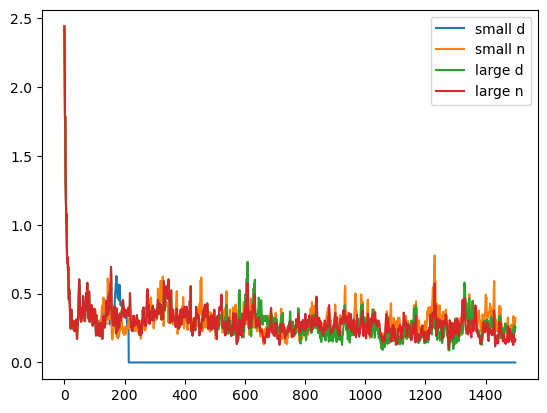

In [15]:
print('starting small training experiment')
dap.runDA(e_small_training_rsfp)
print('starting small training experiment (nearest computation)')
dap.runDA(e_small_training_nearest_rsfp)
print('starting large training experiment')
dap.runDA(e_large_training_rsfp)
print('starting large training experiment (nearest computation)')
dap.runDA(e_large_training_nearest_rsfp)

plt.plot(e_small_training_rsfp.rmse, label='small d')
plt.plot(e_small_training_nearest_rsfp.rmse, label = 'small n')
plt.plot(e_large_training_rsfp.rmse, label = 'large d')
plt.plot(e_large_training_nearest_rsfp.rmse, label='large n')
plt.legend()
plt.show()

In [16]:
path = 'data/direct_v_nearest_pyx_calc/rsfp_'

rsfp_wo_t110_n100_dir = compute_by_direct(path + 'test_data_110.npz', path + 'kde_100.pkl', path + 'maps_100.npz')
rsfp_wo_t120_n100_dir = compute_by_direct(path + 'test_data_120.npz', path + 'kde_100.pkl', path + 'maps_100.npz')
rsfp_wo_t130_n100_dir = compute_by_direct(path + 'test_data_130.npz', path + 'kde_100.pkl', path + 'maps_100.npz')
rsfp_wo_t110_n500_dir = compute_by_direct(path + 'test_data_110.npz', path + 'kde_500.pkl', path + 'maps_500.npz')
rsfp_wo_t120_n500_dir = compute_by_direct(path + 'test_data_120.npz', path + 'kde_500.pkl', path + 'maps_500.npz')
rsfp_wo_t130_n500_dir = compute_by_direct(path + 'test_data_130.npz', path + 'kde_500.pkl', path + 'maps_500.npz')
rsfp_wo_t110_n100_nr = compute_by_nearest(path + 'test_data_110.npz', path + 'kde_100.pkl', path + 'maps_100.npz')
rsfp_wo_t120_n100_nr = compute_by_nearest(path + 'test_data_120.npz', path + 'kde_100.pkl', path + 'maps_100.npz')
rsfp_wo_t130_n100_nr = compute_by_nearest(path + 'test_data_130.npz', path + 'kde_100.pkl', path + 'maps_100.npz')
rsfp_wo_t110_n500_nr = compute_by_nearest(path + 'test_data_110.npz', path + 'kde_500.pkl', path + 'maps_500.npz')
rsfp_wo_t120_n500_nr = compute_by_nearest(path + 'test_data_120.npz', path + 'kde_500.pkl', path + 'maps_500.npz')
rsfp_wo_t130_n500_nr = compute_by_nearest(path + 'test_data_130.npz', path + 'kde_500.pkl', path + 'maps_500.npz')

(1,)


/var/folders/8j/k_hxvb2s6ts__zmjbc2qn9q80000gn/T/ipykernel_27074/1179857395.py:38: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  new_obs_kde[k] = y_kde(Y[k,t,:])


(1,)
(1,)
(1,)
(1,)
(1,)


In [17]:
#%matplotlib notebook
x = np.arange(80)
width=0.4
def rsfp_plot_row(row, size, time):
    plt.figure(figsize=(10, 4))

    if size=='Large':
        if time == '1':
            d1 = rsfp_wo_t110_n500_dir
            d2 = rsfp_wo_t110_n500_nr
        elif time=='2':
            d1 = rsfp_wo_t120_n500_dir
            d2 = rsfp_wo_t120_n500_nr
        elif time=='3':
            d1 = rsfp_wo_t130_n500_dir
            d2 = rsfp_wo_t130_n500_nr
    elif size=='Small':
        if time == '1':
            d1 = rsfp_wo_t110_n100_dir
            d2 = rsfp_wo_t110_n100_nr
        elif time=='2':
            d1 = rsfp_wo_t120_n100_dir
            d2 = rsfp_wo_t120_n100_nr
        elif time=='3':
            d1 = rsfp_wo_t130_n100_dir
            d2 = rsfp_wo_t130_n100_nr

    plt.bar(x - width/2, d1[row], width, label='direct')
    plt.bar(x + width/2, d2[row], width, label='nearest')

    plt.ylim(0,0.07)
    
    plt.legend()
    plt.title(f"Cauchy RSFP Experiment - {size} Training: Obs #{row}")
    plt.xlabel("Ensemble Member")
    plt.ylabel("Computed Particle Weights")
    
    plt.show()

interact(
    rsfp_plot_row,
    row=IntSlider(min=0, max=len(rsfp_wo_t110_n100_dir)-1, step=1, value=0),
    size=RadioButtons(options=['Large', 'Small'], description='Dataset:'),
    time=RadioButtons(options=['1', '2','3'], description='Time:')
)

interactive(children=(IntSlider(value=0, description='row', max=19), RadioButtons(description='Dataset:', opti…

<function __main__.rsfp_plot_row(row, size, time)>

In [18]:
def plot_ens(obs, time):

    if time == '1':
        data = np.load('data/direct_v_nearest_pyx_calc/rsfp_test_data_110.npz')
    elif time == '2':
        data = np.load('data/direct_v_nearest_pyx_calc/rsfp_test_data_120.npz')
    elif time == '3':
        data = np.load('data/direct_v_nearest_pyx_calc/rsfp_test_data_130.npz')

    hxb_data = data['hxb_nbrs']
    y_data = data['Y']

    t = 110 if time == '1' else 120 if time == '2' else 130
    y_t = y_data[:,t,:]
        
    plt.figure(figsize=(10, 4))

    plt.scatter(x, hxb_data[0,obs],s=20, label='ensemble members' , c='black')

    plt.plot(x, np.ones(80) * y_t[obs], c='red', label='Observation')
    
    plt.legend()
    plt.ylim(-10,13)
    plt.title(f"t=130; obs# ={obs}")
    plt.xlabel("Ensemble Member")
    plt.ylabel("Value")
    
    plt.show()

interact(
    plot_ens,
    obs=IntSlider(min=0, max=19, step=1, value=0),
    time=RadioButtons(options=['1', '2','3'], description='Time:')
)

interactive(children=(IntSlider(value=0, description='obs', max=19), RadioButtons(description='Time:', options…

<function __main__.plot_ens(obs, time)>

## This actually looks pretty comparable to the training-on-truth runs, which is nice to see.

# The next thing to look at is what embeddings look like for different state-obs pairs, especially in situations where weights collapsed onto a single particle for no discernible reason.

In [19]:

x_embs = np.zeros((6,51,2000))
y_embs = np.zeros((6,51,2000))

x_trains = np.zeros((6,1,2000))
y_trains = np.zeros((6,1,2000))

map_files = ['maps_100','maps_500','gauss_maps_100','gauss_maps_500','rsfp_maps_100','rsfp_maps_500']
input_stems = ['','','gauss_','gauss_','rsfp_','rsfp_']

cauchy_small=0
cauchy_large=1
gauss_small=2
gauss_large=3
cauchy_rsfp_small=4
cauchy_rsfp_large=5

for i in range(len(map_files)):
    data = np.load(f'data/direct_v_nearest_pyx_calc/{map_files[i]}.npz')
    
    x_trains[i] = data['x_train'][:,:2000]
    y_trains[i] = data['y_train'][:,:2000]
    evec_x, eval_x, a_train_x, bwx = data['evec_x'],data['eval_x'],data['a_train_x'],data['bwx']
    evec_y, eval_y, a_train_y, bwy = data['evec_y'],data['eval_y'],data['a_train_y'],data['bwy']
    
    x_embs[i] = (evec_x * eval_x).T[:,:2000]
    y_embs[i] = (evec_y * eval_y).T[:,:2000]

In [26]:
def plot_embeddings(which, xev1, xev2, yev1, yev2, x_train_sample, y_train_sample, t, obs, ens, synthetic, synth_obs, synth_state):

    test_data = np.load('data/direct_v_nearest_pyx_calc/test_data_110.npz')

    if which == 'small cauchy':
        which = 0
    elif which == 'large cauchy':
        which = 1
    elif which == 'small gauss':
        which = 2
    elif which == 'large gauss':
        which = 3
    elif which == 'small rsfp cauchy':
        which = 4
    elif which == 'large rsfp cauchy':
        which = 5
        
    maps = np.load(f'data/direct_v_nearest_pyx_calc/{map_files[which]}.npz')
    input_data = np.load(f'data/direct_v_nearest_pyx_calc/{input_stems[which]}test_data_{t}.npz')
    
    x_train = maps['x_train']
    y_train = maps['y_train']
    evec_x, eval_x, a_train_x, bwx, knn = maps['evec_x'],maps['eval_x'],maps['a_train_x'],maps['bwx'], maps['knn']
    evec_y, eval_y, a_train_y, bwy = maps['evec_y'],maps['eval_y'],maps['a_train_y'],maps['bwy']
    
    a_train_x = np.asarray(a_train_x).squeeze()
    a_train_y = np.asarray(a_train_y).squeeze()
    
    Y = input_data['Y']
    yt = Y[obs,t,:]
    hxb_nbrs = input_data['hxb_nbrs']
    
    if synthetic:
        
        obs_emb = DAPyr.MISC.diff_map_ext_nystrom(np.array([synth_obs]),y_train.T,evec_y,eval_y,a_train_y,bwy,knn,1) * eval_y
        
        state_emb = DAPyr.MISC.diff_map_ext_nystrom(
              np.array([synth_state]).reshape(1, -1),
              x_train.T,
              evec_x,
              eval_x,
              a_train_x,
              bwx,
              knn,
              1,
        ) * eval_x
    else:

        obs_emb = DAPyr.MISC.diff_map_ext_nystrom(Y[obs,t,:].T,y_train.T,evec_y,eval_y,a_train_y,bwy,knn,1) * eval_y
        
        state_emb = DAPyr.MISC.diff_map_ext_nystrom(
              hxb_nbrs[:, obs, ens].reshape(1, -1),
              x_train.T,
              evec_x,
              eval_x,
              a_train_x,
              bwx,
              knn,
              1,
        ) * eval_x
    
    fig, ax = plt.subplots(1,2, figsize=(8,4))
    x_emb = x_embs[which]
    y_emb = y_embs[which]
    ax[0].scatter(x_emb[xev1], x_emb[xev2])
    ax[0].set_title(f'X embedding: eigenvectors {xev1} vs. {xev2}')
    ax[1].scatter(y_emb[yev1], y_emb[yev2])
    ax[1].set_title(f'Y embedding: eigenvectors {yev1} vs. {yev2}')

    ax[0].scatter(x_emb[xev1,x_train_sample], x_emb[xev2,x_train_sample], c='red')
    ax[1].scatter(y_emb[yev1,y_train_sample], y_emb[yev2,y_train_sample], c='red')

    ax[0].text(0.03, 0.05, f'Training Sample: {x_train[:,x_train_sample]}', horizontalalignment='left', verticalalignment='center', transform = ax[0].transAxes)
    ax[0].text(0.03, 0.12, f'from nystrom: {hxb_nbrs[:,obs,ens]}', horizontalalignment='left', verticalalignment='center', transform = ax[0].transAxes)
    ax[1].text(0.03, 0.05, f'Training Sample: {y_train[:,y_train_sample]}', horizontalalignment='left', verticalalignment='center', transform = ax[1].transAxes)
    ax[1].text(0.03, 0.12, f'from nystrom: {Y[obs,t,:]}', horizontalalignment='left', verticalalignment='center', transform = ax[1].transAxes)

    ax[0].scatter(state_emb[0,xev1], state_emb[0,xev2], c='magenta')
    ax[1].scatter(obs_emb[0,yev1], obs_emb[0,yev2], c='magenta')

interact(
    plot_embeddings,
    xev1=IntSlider(min=1, max=50, step=1, value=1),
    xev2=IntSlider(min=1, max=50, step=1, value=2),
    yev1=IntSlider(min=1, max=50, step=1, value=1),
    yev2=IntSlider(min=1, max=50, step=1, value=2),
    t=IntSlider(min=110, max=130, step=10, value=110),
    obs=IntSlider(min=0, max=19, step=1, value=0),
    ens=IntSlider(min=0, max=79, step=1, value=0),
    x_train_sample=IntSlider(min=0, max=1999, step=1, value=0),
    y_train_sample=IntSlider(min=0, max=1999, step=1, value=0),
    synth_obs=FloatSlider(min=-50, max=50, step=0.2, value=0),
    synth_state=FloatSlider(min=-50, max=50, step=0.2, value=0),
    which=RadioButtons(options=['small cauchy','large cauchy','small gauss','large gauss','small rsfp cauchy','large rsfp cauchy'], description='Dataset:'),
    synthetic=Checkbox(options=['True','False'], description='Synthetic Data to Nystrom:'),
);

interactive(children=(RadioButtons(description='Dataset:', options=('small cauchy', 'large cauchy', 'small gau…

In [21]:
def compute_by_direct_synth(ens, obs, kde_file, map_file):
    with open(kde_file, "rb") as f:
        y_kde = pickle.load(f)
    
    hxb_nbrs = ens
    Y = np.array([obs])

    map_info = np.load(map_file)
    x_train = map_info['x_train']
    y_train = map_info['y_train']
    evec_x = map_info['evec_x']           
    eval_x = map_info['eval_x']            
    a_train_x = map_info['a_train_x']      
    evec_y = map_info['evec_y']         
    eval_y = map_info['eval_y']         
    a_train_y = map_info['a_train_y']        
    cov_embedding = map_info['cov_embedding']
    bwx = map_info['bwx']
    bwy = map_info['bwy']
    knn=map_info['knn']
    Ns=1

    a_train_x = np.asarray(a_train_x).squeeze()
    a_train_y = np.asarray(a_train_y).squeeze()


    Ny, Ne, Neig = 1, 80, 50

    V_new_obs = np.zeros((Ny, Neig+1))
    V_new_state = np.zeros((Ny, Ne, Neig+1))
    new_obs_kde = np.zeros(Ny)

    for k in range(Ny):
          # print('k is {}p'.format(k))
          V_new_obs[k] = DAPyr.MISC.diff_map_ext_nystrom(Y.T,y_train.T,evec_y,eval_y,a_train_y,bwy,knn,1);
          new_obs_kde[k] = y_kde(obs)

          for n in range(Ne):
                V_new_state[k,n] = DAPyr.MISC.diff_map_ext_nystrom(
                      hxb_nbrs[:, k, n].reshape(1, -1),
                      x_train.T,
                      evec_x,
                      eval_x,
                      a_train_x,
                      bwx,
                      knn,
                      Ns,
                )
    temp = V_new_obs @ cov_embedding
    wo2 = np.einsum('kd, knd->kn', temp, V_new_state)
    wo2 *= new_obs_kde[:,None]
    
    wo2 = np.maximum(wo2, 0)
    #wo2 = np.real(wo2) + 1e-40
    for k in range(Ny):
          wo2[k, :] /= np.sum(wo2[k, :])
    return wo2

    
def compute_by_nearest_synth(ens, obs, kde_file, map_file):
    with open(kde_file, "rb") as f:
        y_kde = pickle.load(f)
    
    hxb_nbrs = ens
    Y = np.array([obs])

    map_info = np.load(map_file)
    x_train = map_info['x_train']
    y_train = map_info['y_train']
    evec_x = map_info['evec_x']           
    eval_x = map_info['eval_x']            
    a_train_x = map_info['a_train_x']      
    evec_y = map_info['evec_y']         
    eval_y = map_info['eval_y']         
    a_train_y = map_info['a_train_y']        
    cov_embedding = map_info['cov_embedding']
    bwx = map_info['bwx']
    bwy = map_info['bwy']
    knn=map_info['knn']
    pab=map_info['pab']
    Ns=1

    x_emb = (evec_x * eval_x).T
    y_emb = (evec_y * eval_y).T


    a_train_x = np.asarray(a_train_x).squeeze()
    a_train_y = np.asarray(a_train_y).squeeze()

    nle_type=4

    Ny, Ne, Neig = 1, 80, 50
    wo = np.zeros((Ny,Ne))

    for k in range(Ny):
      if nle_type >= 4 :
            # print('k is {}p'.format(k))
            obs_emb = DAPyr.MISC.diff_map_ext_nystrom(Y.T,y_train.T,evec_y,eval_y,a_train_y,bwy,knn,1);
            V_new_obs = obs_emb
            obs_emb *= eval_y
            ind2 = np.argmin(np.sum((obs_emb.T - y_emb) ** 2, axis=0))
      for n in range(Ne):
            if nle_type < 4:
                  obs_emb = DAPyr.MISC.diff_map_ext_nystrom(
      # y_train[ts:te] = Y[t,0::tof]
                        (Y[k,t,:] - hxb_nbrs[(Nxy - 1) // 2, k, n]).T,
                        y_train.T,
                        evec_y,
                        eval_y,
                        a_train_y,
                        bwy,
                        knn,
                        1,
                  )
                  obs_emb *= eval_y  # Element-wise multiplication along columns
                  ind2 = np.argmin(np.sum((obs_emb.T - y_emb) ** 2, axis=0))
            # Find nearest state on manifold
            state_emb = DAPyr.MISC.diff_map_ext_nystrom(
                  hxb_nbrs[:, k, n].reshape(1, -1),
                  x_train.T,
                  evec_x,
                  eval_x,
                  a_train_x,
                  bwx,
                  knn,
                  Ns,
            )
            state_emb *= eval_x  # Element-wise multiplication along columns
            ind1 = np.argmin(np.sum((state_emb.T - x_emb) ** 2, axis=0))
            wo[k,n] = pab[ind2, ind1]

# sum of normalized likelihoods for a given observation equals one
      wo[k, :] /= np.sum(wo[k, :])
    return wo


In [29]:

def plot_weights_from_synthetic(ens_mean, ens_var, obs, size, seed, which):
    fig, axs = plt.subplots(2)
    rng = np.random.default_rng(seed)
    ens = rng.normal(ens_mean, np.sqrt(ens_var), 80).reshape(1,1,80)

    if which == 'Cauchy':
        wo_dir = compute_by_direct_synth(ens, obs, f'data/direct_v_nearest_pyx_calc/kde_{size}.pkl',f'data/direct_v_nearest_pyx_calc/maps_{size}.npz') 
        wo_nrs = compute_by_nearest_synth(ens, obs, f'data/direct_v_nearest_pyx_calc/kde_{size}.pkl',f'data/direct_v_nearest_pyx_calc/maps_{size}.npz') 
    elif which == 'Gaussian':
        wo_dir = compute_by_direct_synth(ens, obs, f'data/direct_v_nearest_pyx_calc/gauss_kde_{size}.pkl',f'data/direct_v_nearest_pyx_calc/gauss_maps_{size}.npz') 
        wo_nrs = compute_by_nearest_synth(ens, obs, f'data/direct_v_nearest_pyx_calc/gauss_kde_{size}.pkl',f'data/direct_v_nearest_pyx_calc/gauss_maps_{size}.npz') 

    d1 = wo_dir[0]
    d2 = wo_nrs[0]
    print(d1.shape)

    width=0.4
    x = np.arange(80)
    axs[0].bar(x - width/2, d1, width, label='direct')
    axs[0].bar(x + width/2, d2, width, label='nearest')

    axs[0].set_ylim(0,0.1)
    
    axs[0].legend()
    axs[0].set_title(f"Synthetic Ensemble Experiment - n={size} Training")
    axs[0].set_xlabel("Ensemble Member")
    axs[0].set_ylabel("Computed Particle Weights")

    axs[1].scatter(x, ens, label='ensemble', c='k')
    axs[1].plot(x, np.ones(80) * obs, c='r', label='obs')
    axs[1].legend()
    axs[1].set_ylim(-20,20)

    plt.tight_layout()
    plt.show()
    
interact(
    plot_weights_from_synthetic,
    ens_mean=FloatSlider(min=-20, max=20, step=0.1, value=0),
    seed=IntSlider(min=0, max=100, step=1, value=0),
    ens_var=FloatSlider(min=0.2, max=10, step=0.1, value=0.2),
    obs=FloatSlider(min=-100, max=100, step=0.1, value=0),
    size=RadioButtons(options=['100','500'], description='Training Size:'),
    which=RadioButtons(options=['Cauchy','Gaussian'], description='Errors:'),
);

    

interactive(children=(FloatSlider(value=0.0, description='ens_mean', max=20.0, min=-20.0), FloatSlider(value=0…